# Tutorial 5: Trajectory Selection

History matching identifies the **NROY region** — the part of parameter space *Not Ruled Out Yet* by the available evidence. But for stochastic models, knowing *which parameters are plausible* is only half the story. The same parameters with different random seeds can produce very different epidemic curves.

**Trajectory selection** is the post-calibration step that picks specific `(parameter set, random seed)` pairs whose simulated outputs are consistent with the observed data. The result is a set of **plausible trajectories** — not just plausible parameters.

This tutorial uses **Sampling Importance Resampling (SIR)**¹ to select trajectories:

1. Sample `(β, γ, seed)` triples from the NROY region
2. Run the stochastic simulator for each triple → get an ensemble of incidence curves
3. Weight each trajectory by how well it matches the observations (pseudo-likelihood)
4. Resample proportional to those weights → the selected trajectory set

---
¹ *Yes, the acronym matches the epidemic model. This is intentional and delightful.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import history_matching as hm
from model import SIR, generate_observed_data

/Users/dklein/GIT/history_matching/.venv/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Generate synthetic observations

We generate a synthetic epidemic using a known `(β, γ)` pair. In a real study this would be replaced by actual surveillance data.

True parameters:  β=1.3, γ=0.35  (R₀ ≈ 3.71)
Observed peak:    988 cases on day 5
Total cases:      4814  (attack rate 96.3%)


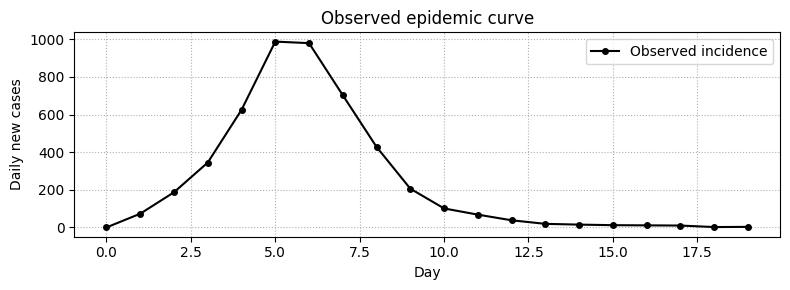

In [2]:
POPULATION       = 5_000
SEED_INFECTIONS  = 50
BETA_TRUE        = 1.3
GAMMA_TRUE       = 0.35

obs_incidence, obs_model = generate_observed_data(
    beta_true        = BETA_TRUE,
    gamma_true       = GAMMA_TRUE,
    population_size  = POPULATION,
    n_seed_infections= SEED_INFECTIONS,
    seed=42,
)

print(f"True parameters:  β={BETA_TRUE}, γ={GAMMA_TRUE}  (R₀ ≈ {BETA_TRUE/GAMMA_TRUE:.2f})")
print(f"Observed peak:    {obs_incidence.max():.0f} cases on day {obs_incidence.argmax()}")
print(f"Total cases:      {obs_incidence.sum():.0f}  (attack rate {obs_incidence.sum()/POPULATION:.1%})")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(obs_incidence.values, 'ko-', ms=4, lw=1.5, label='Observed incidence')
ax.set_xlabel('Day')
ax.set_ylabel('Daily new cases')
ax.set_title('Observed epidemic curve')
ax.legend()
ax.grid(ls=':')
fig.tight_layout()

## 2. Run history matching to identify the NROY region

We calibrate using two summary statistics — peak incidence and attack rate. Using summary statistics (rather than the full time series) for history matching keeps the emulation problem low-dimensional. The full time-series comparison is reserved for the trajectory selection step, where we want a finer filter.

> **Note on stochasticity.** The simulator below does *not* fix a random seed. Each call is a fresh stochastic draw. This is intentional: the GPR emulator learns the expected behaviour across the stochastic distribution, which is what we want for implausibility scoring.

In [3]:
def run_sir(samples: pd.DataFrame) -> pd.DataFrame:
    """Simulator wrapper for history matching — returns summary statistics."""
    rows = []
    for _, row in samples.iterrows():
        model = SIR(
            beta  = row['beta'],
            gamma = row['gamma'],
            s0    = POPULATION - SEED_INFECTIONS,
            i0    = SEED_INFECTIONS,
            # No seed: stochastic output; emulator learns the mean
        )
        inc = model.get_incidence()
        rows.append({
            'peak_incidence': float(inc.max()),
            'attack_rate':    float(inc.sum() / POPULATION),
        })
    return pd.DataFrame(rows)

In [4]:
obs_peak = float(obs_incidence.max())
obs_ar   = float(obs_incidence.sum() / POPULATION)

# Allow ±15% tolerance on peak and ±10% on attack rate.
# These reflect realistic uncertainty in epidemic surveillance.
engine = (
    hm.HistoryMatchingBuilder
    .from_data(
        parameter_bounds = {'beta': (0.5, 2.5), 'gamma': (0.1, 0.8)},
        observations     = {
            'peak_incidence': (obs_peak,  obs_peak * 0.15),
            'attack_rate':    (obs_ar,    obs_ar   * 0.10),
        },
    )
    .with_emulator_type('gpr')
    .with_samples_per_iteration(300)
    .with_max_iterations(3)
    .build()
)
engine.set_simulation_function(run_sir)

results = engine.run()
print(engine)

/Users/dklein/GIT/history_matching/history_matching/builder.py:423: UserWarning: No sampling strategy specified. Using Latin Hypercube Sampling.
  warnings.warn("No sampling strategy specified. Using Latin Hypercube Sampling.")
/Users/dklein/GIT/history_matching/history_matching/builder.py:428: UserWarning: No feature selection specified. Using automatic selection with Fano factor.
  warnings.warn("No feature selection specified. Using automatic selection with Fano factor.")
2026-03-19 18:48:39.683594: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-03-19 18:48:39.683736: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-19 18:48:39.683743: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1773960519.684012 116371353 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:177396

2026-03-19 18:48:40.924221: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


HistoryMatchingEngine(
  state=completed,
  iteration=3/3,
  acceptance_rate=0.613,
  emulators_trained=3,
  auto_reduce_space=False
)


## 3. Inspect the NROY region

After history matching the parameter samples from the final iteration were drawn by rejection-sampling the full prior against all trained emulators. They represent a draw from the current NROY region.

NROY parameter pool: 300 samples from the final NROY region


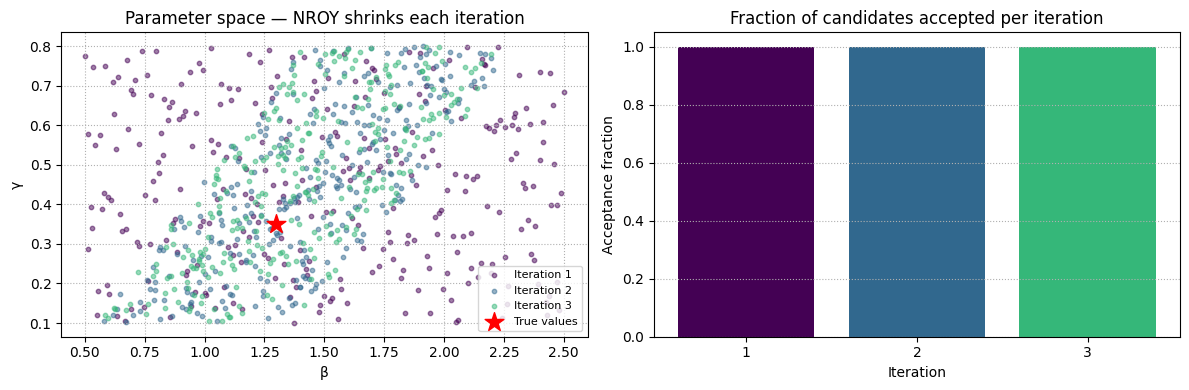

In [5]:
# Collect samples from all iterations to visualise the space reduction
all_samples = pd.concat(
    [r.samples.assign(iteration=r.iteration) for r in results],
    ignore_index=True,
)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

cmap  = plt.get_cmap('viridis')
n_iter = len(results)
for it in range(1, n_iter + 1):
    df = all_samples[all_samples['iteration'] == it]
    axs[0].scatter(df['beta'], df['gamma'],
                   s=10, alpha=0.5,
                   color=cmap((it - 1) / n_iter),
                   label=f'Iteration {it}')

axs[0].scatter([BETA_TRUE], [GAMMA_TRUE], marker='*', s=200,
               c='red', zorder=5, label='True values')
axs[0].set_xlabel('β')
axs[0].set_ylabel('γ')
axs[0].set_title('Parameter space — NROY shrinks each iteration')
axs[0].legend(fontsize=8)
axs[0].grid(ls=':')

# Acceptance rate per iteration
iters = [r.iteration for r in results]
acceptance = [r.non_implausible_fraction for r in results]
axs[1].bar(iters, acceptance, color=[cmap((i) / n_iter) for i in range(n_iter)])
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Acceptance fraction')
axs[1].set_title('Fraction of candidates accepted per iteration')
axs[1].set_xticks(iters)
axs[1].grid(ls=':', axis='y')

fig.tight_layout()

# NROY pool for trajectory selection = final iteration samples
nroy_samples = results[-1].samples.copy()
print(f"NROY parameter pool: {len(nroy_samples)} samples from the final NROY region")

## 4. Generate a trajectory ensemble

For each parameter set in the NROY pool we run the stochastic model with `N_SEEDS` different random seeds, producing a full ensemble of plausible epidemic curves. This is the **prior ensemble** before trajectory selection — all trajectories are consistent with the summary-statistic observations used in history matching, but many may differ substantially from the observed time series.

In [6]:
N_SEEDS = 20  # seeds per parameter set
N_DAYS  = obs_incidence.shape[0]

ensemble = []
for _, params in nroy_samples.iterrows():
    for seed in range(N_SEEDS):
        model = SIR(
            beta  = params['beta'],
            gamma = params['gamma'],
            s0    = POPULATION - SEED_INFECTIONS,
            i0    = SEED_INFECTIONS,
            seed  = seed,
        )
        inc = model.get_incidence()
        ensemble.append({
            'beta':      params['beta'],
            'gamma':     params['gamma'],
            'seed':      seed,
            'incidence': inc[:N_DAYS],
        })

ensemble_df = pd.DataFrame(ensemble)
print(f"Ensemble size: {len(ensemble_df)} trajectories  "
      f"({len(nroy_samples)} param sets × {N_SEEDS} seeds)")

Ensemble size: 6000 trajectories  (300 param sets × 20 seeds)


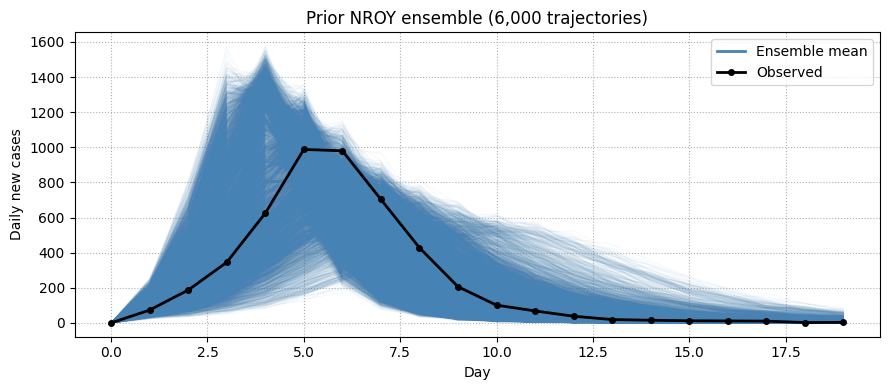

In [7]:
inc_matrix = np.vstack(ensemble_df['incidence'].values)  # shape (n_traj, n_days)

fig, ax = plt.subplots(figsize=(9, 4))
for row in inc_matrix:
    ax.plot(row, color='steelblue', alpha=0.05, lw=0.8)
ax.plot(inc_matrix.mean(axis=0), color='steelblue', lw=2, label='Ensemble mean')
ax.plot(obs_incidence.values, 'ko-', ms=4, lw=2, label='Observed', zorder=5)
ax.set_xlabel('Day')
ax.set_ylabel('Daily new cases')
ax.set_title(f'Prior NROY ensemble ({len(ensemble_df):,} trajectories)')
ax.legend()
ax.grid(ls=':')
fig.tight_layout()

## 5. Weight trajectories by pseudo-likelihood

We score each trajectory against the observed incidence curve using a **Gaussian pseudo-likelihood**:

$$w_i = \exp\!\left(-\frac{d_i^2}{2\,\varepsilon^2}\right), \qquad d_i = \sqrt{\frac{1}{T}\sum_{t=1}^T\left(y_i(t) - y_{\mathrm{obs}}(t)\right)^2}$$

where $d_i$ is the RMSE between trajectory $i$ and the observed data, and $\varepsilon$ is a **tolerance** that controls how strict the selection is.

- **Large ε** → lenient: weights spread broadly, selected set ≈ random draw from NROY  
- **Small ε** → strict: only trajectories very close to the observed curve get non-negligible weight

A practical starting point is $\varepsilon \approx$ one standard deviation of the observed peak.

Tolerance ε = 98.8 cases/day
Effective sample size: 3136  (out of 6,000 total)


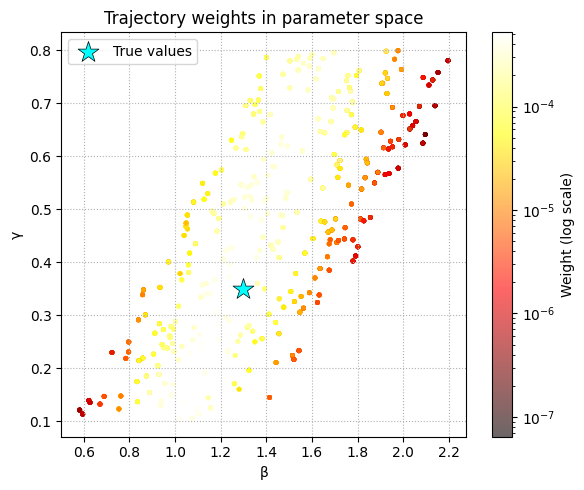

In [8]:
def gaussian_weights(inc_matrix: np.ndarray, obs: np.ndarray, epsilon: float) -> np.ndarray:
    """
    Compute normalised pseudo-likelihood weights for each trajectory.

    Args:
        inc_matrix: Array of shape (n_traj, n_days) — simulated trajectories.
        obs:        Array of shape (n_days,)         — observed incidence.
        epsilon:    Tolerance (RMSE scale).  Smaller = stricter selection.

    Returns:
        Normalised weight array of shape (n_traj,).
    """
    rmse = np.sqrt(np.mean((inc_matrix - obs[np.newaxis, :]) ** 2, axis=1))
    w    = np.exp(-0.5 * (rmse / epsilon) ** 2)
    total = w.sum()
    if total == 0:
        raise ValueError("All weights are zero — try a larger epsilon.")
    return w / total


# Tolerance ≈ 10 % of the peak value — a reasonable starting point
epsilon = obs_peak * 0.10

obs_array = obs_incidence.values[:N_DAYS]
weights   = gaussian_weights(inc_matrix, obs_array, epsilon=epsilon)

print(f"Tolerance ε = {epsilon:.1f} cases/day")
print(f"Effective sample size: {1 / (weights**2).sum():.0f}  "
      f"(out of {len(weights):,} total)")

# Scatter: parameter space coloured by weight
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    ensemble_df['beta'], ensemble_df['gamma'],
    c=weights, cmap='hot', s=6, alpha=0.6, norm=mcolors.LogNorm(),
)
ax.scatter([BETA_TRUE], [GAMMA_TRUE], marker='*', s=250, c='cyan',
           edgecolors='k', lw=0.5, zorder=5, label='True values')
plt.colorbar(sc, ax=ax, label='Weight (log scale)')
ax.set_xlabel('β')
ax.set_ylabel('γ')
ax.set_title('Trajectory weights in parameter space')
ax.legend()
ax.grid(ls=':')
fig.tight_layout()

## 6. Importance resampling — select the final trajectory set

We draw `N_SELECT` trajectories without replacement from the ensemble, proportional to their weights. The result is a **volume-manageable set of plausible trajectories** that can be used for downstream analysis (forecasting quantiles, reporting representative epidemic curves, etc.).

In [9]:
N_SELECT  = 50   # number of trajectories to retain
rng       = np.random.default_rng(seed=0)

selected_idx = rng.choice(
    len(ensemble_df),
    size    = N_SELECT,
    replace = False,
    p       = weights,
)
selected_df  = ensemble_df.iloc[selected_idx].copy()
selected_inc = inc_matrix[selected_idx]

print(f"Selected {N_SELECT} trajectories")
print(f"β range in selected set:  {selected_df['beta'].min():.3f} – {selected_df['beta'].max():.3f}")
print(f"γ range in selected set:  {selected_df['gamma'].min():.3f} – {selected_df['gamma'].max():.3f}")
print(f"Seeds used: {sorted(selected_df['seed'].unique())}")

Selected 50 trajectories
β range in selected set:  0.874 – 1.921
γ range in selected set:  0.106 – 0.765
Seeds used: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]


## 7. Visualise the selected trajectories

Compare the full prior ensemble (grey) against the selected trajectories (coloured) and the observations (black). The selected set should be visually consistent with the observed curve, whereas the full ensemble is much broader.

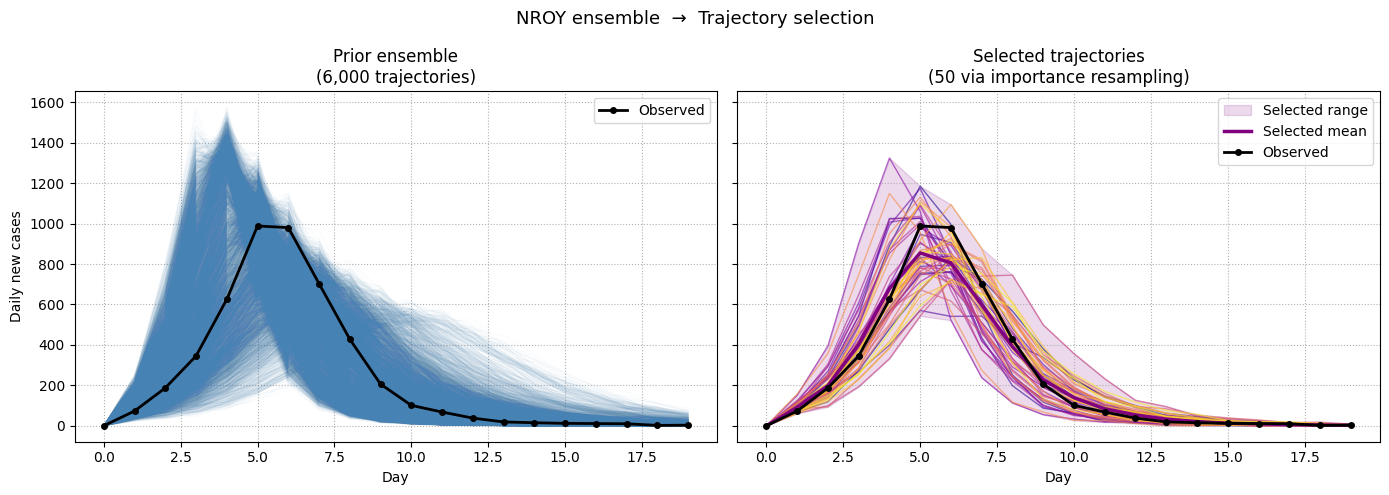

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Left panel: full prior ensemble ---
for row in inc_matrix:
    axs[0].plot(row, color='steelblue', alpha=0.04, lw=0.7)
axs[0].plot(obs_array, 'ko-', ms=4, lw=2, label='Observed', zorder=5)
axs[0].set_title(f'Prior ensemble\n({len(inc_matrix):,} trajectories)')
axs[0].set_xlabel('Day')
axs[0].set_ylabel('Daily new cases')
axs[0].legend()
axs[0].grid(ls=':')

# --- Right panel: selected trajectories ---
cmap_sel = plt.get_cmap('plasma')
for k, row in enumerate(selected_inc):
    axs[1].plot(row, color=cmap_sel(k / N_SELECT), alpha=0.6, lw=1.0)
axs[1].fill_between(
    range(N_DAYS),
    selected_inc.min(axis=0),
    selected_inc.max(axis=0),
    alpha=0.15, color='purple', label='Selected range',
)
axs[1].plot(selected_inc.mean(axis=0), color='purple', lw=2.5, label='Selected mean')
axs[1].plot(obs_array, 'ko-', ms=4, lw=2, label='Observed', zorder=5)
axs[1].set_title(f'Selected trajectories\n({N_SELECT} via importance resampling)')
axs[1].set_xlabel('Day')
axs[1].legend()
axs[1].grid(ls=':')

fig.suptitle('NROY ensemble  →  Trajectory selection', fontsize=13)
fig.tight_layout()

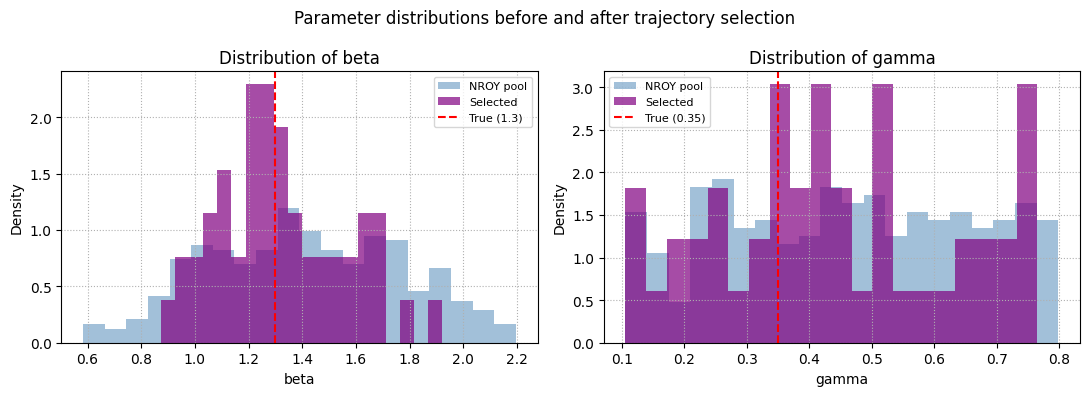

In [11]:
# Parameter distributions: NROY pool vs. selected set
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

for ax, param, true_val in zip(axs, ['beta', 'gamma'], [BETA_TRUE, GAMMA_TRUE]):
    ax.hist(nroy_samples[param], bins=20, density=True,
            alpha=0.5, color='steelblue', label='NROY pool')
    ax.hist(selected_df[param], bins=20, density=True,
            alpha=0.7, color='purple', label='Selected')
    ax.axvline(true_val, color='red', ls='--', lw=1.5, label=f'True ({true_val})')
    ax.set_xlabel(param)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of {param}')
    ax.legend(fontsize=8)
    ax.grid(ls=':')

fig.suptitle('Parameter distributions before and after trajectory selection', fontsize=12)
fig.tight_layout()

## 8. Effect of tolerance ε

The tolerance `ε` is the key tuning parameter. Here we sweep over several values to show the trade-off between **specificity** (small ε → selected trajectories are close to the observed data) and **coverage** (large ε → selected trajectories span the full NROY ensemble).

A useful diagnostic is the **effective sample size** $N_{\mathrm{eff}} = \left(\sum_i w_i^2\right)^{-1}$. When $N_{\mathrm{eff}} \ll N$ the weight distribution is too concentrated; when $N_{\mathrm{eff}} \approx N$ the selection is almost uniform (lenient).

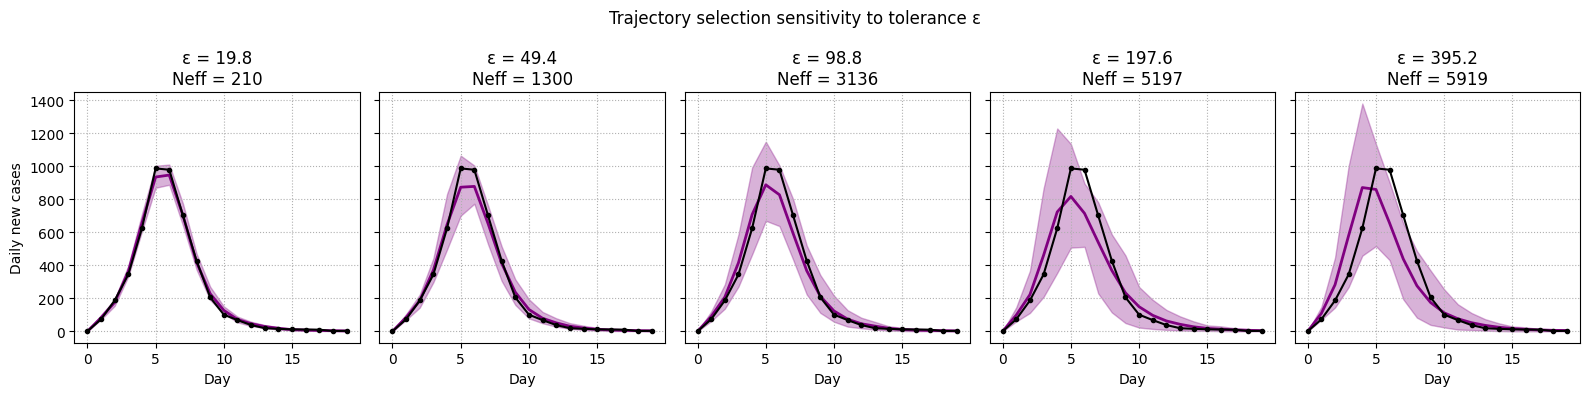

In [12]:
epsilons = [obs_peak * f for f in [0.02, 0.05, 0.10, 0.20, 0.40]]

fig, axs = plt.subplots(1, len(epsilons), figsize=(16, 4), sharey=True)

for ax, eps in zip(axs, epsilons):
    w   = gaussian_weights(inc_matrix, obs_array, epsilon=eps)
    nef = 1 / (w**2).sum()

    idx_sel = rng.choice(len(ensemble_df), size=N_SELECT, replace=False, p=w)
    sel_inc = inc_matrix[idx_sel]

    ax.fill_between(
        range(N_DAYS),
        np.percentile(sel_inc, 10, axis=0),
        np.percentile(sel_inc, 90, axis=0),
        alpha=0.3, color='purple', label='10–90 pct',
    )
    ax.plot(sel_inc.mean(axis=0), color='purple', lw=2)
    ax.plot(obs_array, 'ko-', ms=3, lw=1.5, zorder=5)
    ax.set_title(f'ε = {eps:.1f}\nNeff = {nef:.0f}')
    ax.set_xlabel('Day')
    ax.grid(ls=':')

axs[0].set_ylabel('Daily new cases')
fig.suptitle('Trajectory selection sensitivity to tolerance ε', fontsize=12)
fig.tight_layout()

## Summary

| Step | What it does | Output |
|------|-------------|--------|
| History matching | Eliminates implausible regions of parameter space using emulators | NROY parameter samples |
| Trajectory ensemble | Runs the stochastic model at NROY parameters × multiple seeds | Large ensemble of candidate trajectories |
| Pseudo-likelihood weighting | Scores each trajectory by how closely it matches the observed data | Weight per `(parameter, seed)` pair |
| Importance resampling | Draws a tractable set proportional to weights | Selected plausible trajectories |

### Key design choices

**Why use summary statistics for HM but full time series for trajectory selection?**  
History matching with the full time series would require one emulator per day — high-dimensional and expensive. Summary statistics keep HM tractable. The trajectory selection step then acts as a second, finer filter using the full data.

**How to choose ε?**  
Start with ε ≈ 10% of the observed peak. Check the effective sample size — aim for $N_{\mathrm{eff}} \gtrsim 50$. If the selected trajectories look too broad, tighten ε. If they look implausibly narrow, relax it.

**Using the selected trajectories**  
Each selected `(β, γ, seed)` triple is a complete, reproducible simulation run. You can re-run these with the full model (e.g., longer time horizon, additional compartments) to generate matched forecasts or counterfactuals.